# Two borrowed inputs in a phase-flip oracle

This study transcribes the **16-wire reference and 14-wire candidate** supplied in the two screenshots, targeting human wire 10 (`q9`). It checks all 512 input assignments, the complete phase action and workspace restoration, and coherent states entangled with an external reference. No synthesis algorithms are changed.

**Result:** the two-qubit reduction is valid for the transcribed circuits when used as compute–Z–uncompute. The pictured target also simplifies to `x0 AND x6`; thus these screenshots alone do not establish a resource advantage over Boolean simplification. A separately labeled control-polarity variant below exercises a nontrivial output predicate.

Run from the repository root with the existing notebook environment:
```bash
uv run --no-sync logique notebook run experiments/studies/guarded_phase_oracle_two_ancillas.ipynb --offline
```
Source outputs remain empty; the runner saves an executed copy and provenance in `dump/`. No native synthesis, network access, or hardware is required.

## 1. Screenshot interpretation and wire contract

- Wires are numbered top to bottom: human wires 1–9 are arbitrary inputs `q0..q8`; human wire 10 is the clean output `q9`; all lower wires start at zero.
- Filled controls mean 1; open controls mean 0; circled plus means X. The nine initial H gates prepare the screenshot's uniform input and are **not part of the compute circuit**.
- Green “On” boxes are conditional probability displays, not reset or postselection gates. Standalone control dots without a target have no action. Quirk's [probability-display implementation](https://github.com/Strilanc/Quirk/blob/master/src/gates/ProbabilityDisplay.js) declares no state-vector effect, and its [drawing code](https://github.com/Strilanc/Quirk/blob/master/src/draw/MathPainter.js) renders near-100% probability as “On”.
- The candidate borrows `q0` and `q6`. They need not retain their original values at the compute midpoint. They **must** be restored after uncomputation.
- We manually transcribed the screenshots, not an exported Quirk circuit. The gate tables, diagrams, and all displayed wire marginals below make this interpretation reviewable.

| Resource | Reference | Candidate |
|---|---:|---:|
| Input wires | 9 | 9 |
| Clean output wire | 1 | 1 |
| Dedicated scratch wires | 6 | 4 |
| Total wires | 16 | 14 |

The known-value resource is conditional: after `q10 = x0 AND x6`, both `q0` and `q6` equal 1 on the `q10=1` branch. See [Khattar and Gidney (2025)](https://quantum-journal.org/papers/q-2025-05-21-1752/) for the general conditionally clean ancilla framework.

### Supplied reference images

Image #1 (16 wires):

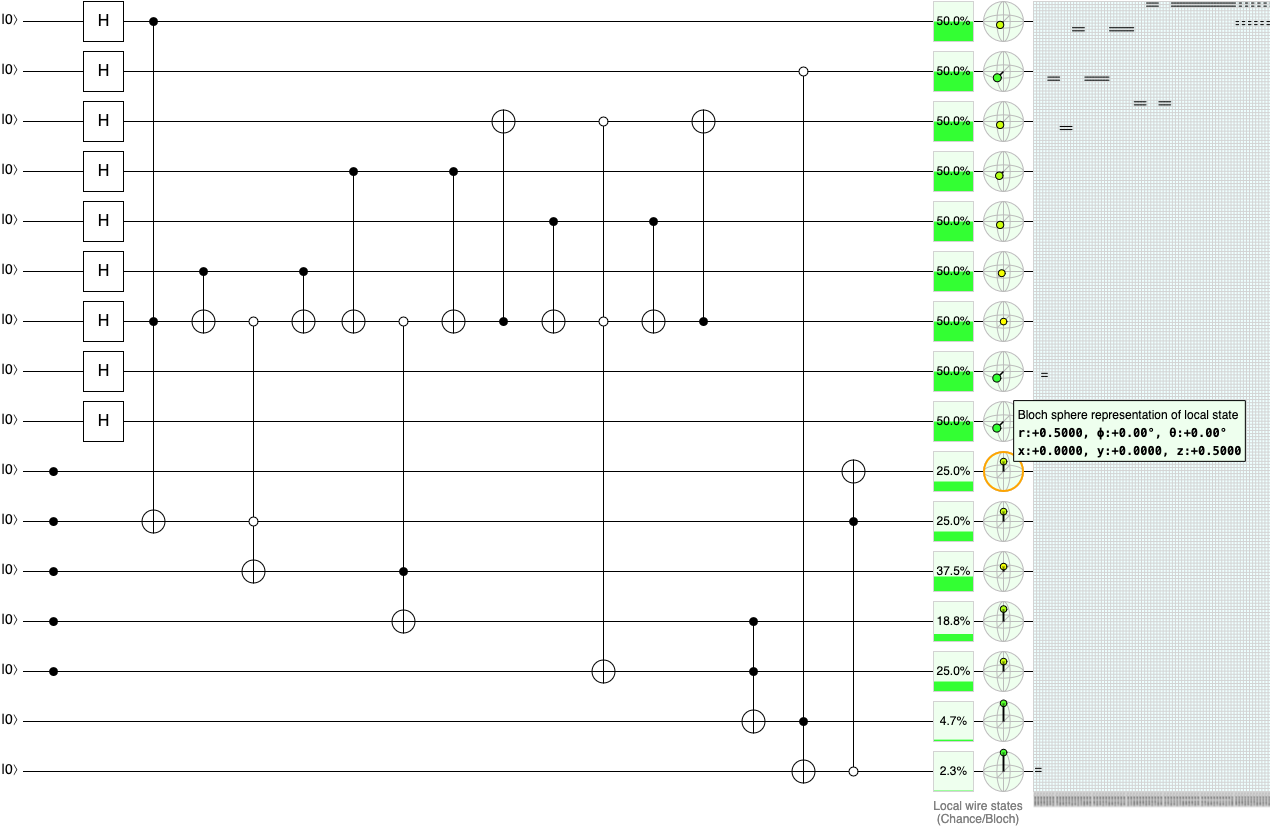

Image #2 (14 wires):

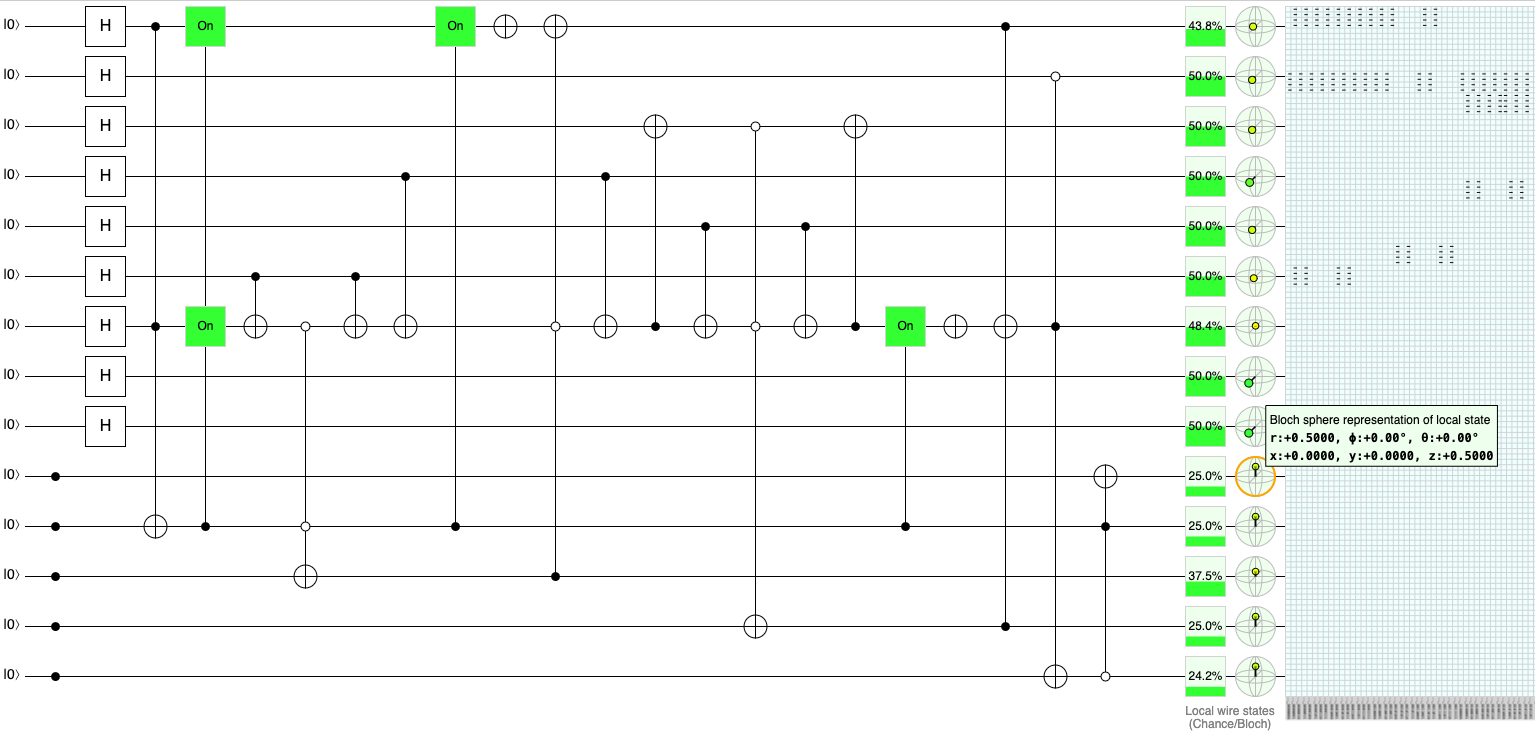

In [ ]:
from importlib.metadata import version
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.circuit.library import XGate
from qiskit.quantum_info import Operator, Statevector
from logique.benchmarks.runner import new_run_directory
import matplotlib.pyplot as plt

ATOL = 1e-10
N_INPUTS = 9
TARGET = 9
OUT = (
    Path(os.environ["LOGIQUE_OUTPUT"])
    if "LOGIQUE_OUTPUT" in os.environ
    else new_run_directory()
)
print({package: version(package) for package in ("qiskit", "numpy", "nbformat")})
print("Artifacts:", OUT)

## 2. Literal gate transcription

Each entry is `(target, ((control, required_value), ...))`, in temporal order. Controlled-X polarities are encoded with the first control as the least-significant bit of Qiskit's `ctrl_state`. Display-only columns are omitted.

In [ ]:
REFERENCE_GATES = [
    (10, ((0, 1), (6, 1))),
    (6, ((5, 1),)),
    (11, ((6, 0), (10, 0))),
    (6, ((5, 1),)),
    (6, ((3, 1),)),
    (12, ((6, 0), (11, 1))),
    (6, ((3, 1),)),
    (2, ((6, 1),)),
    (6, ((4, 1),)),
    (13, ((2, 0), (6, 0))),
    (6, ((4, 1),)),
    (2, ((6, 1),)),
    (14, ((12, 1), (13, 1))),
    (15, ((1, 0), (14, 1))),
    (9, ((10, 1), (15, 0))),
]
CANDIDATE_GATES = [
    (10, ((0, 1), (6, 1))),
    (6, ((5, 1),)),
    (11, ((6, 0), (10, 0))),
    (6, ((5, 1),)),
    (6, ((3, 1),)),
    (0, ()),
    (0, ((6, 0), (11, 1))),
    (6, ((3, 1),)),
    (2, ((6, 1),)),
    (6, ((4, 1),)),
    (12, ((2, 0), (6, 0))),
    (6, ((4, 1),)),
    (2, ((6, 1),)),
    (6, ()),
    (6, ((0, 1), (12, 1))),
    (13, ((1, 0), (6, 1))),
    (9, ((10, 1), (13, 0))),
]


def build_compute(gates: list, width: int, name: str) -> QuantumCircuit:
    """Build exact controlled-X gates, preserving open-control semantics."""
    circuit = QuantumCircuit(width, name=name)
    for target, controls in gates:
        if not controls:
            circuit.x(target)
        else:
            polarity = sum(value << i for i, (_, value) in enumerate(controls))
            gate = XGate().control(len(controls), ctrl_state=polarity)
            circuit.append(gate, [q for q, _ in controls] + [target])
    return circuit


reference = build_compute(REFERENCE_GATES, 16, "reference")
candidate = build_compute(CANDIDATE_GATES, 14, "borrowed")
for circuit, gates in ((reference, REFERENCE_GATES), (candidate, CANDIDATE_GATES)):
    print(circuit.name)
    display(
        pd.DataFrame(
            [
                {
                    "step": i + 1,
                    "target": f"q{target}",
                    "controls": ", ".join(f"q{q}={value}" for q, value in controls)
                    or "none",
                }
                for i, (target, controls) in enumerate(gates)
            ]
        )
    )
    fig = circuit.draw(output="mpl", fold=-1)
    display(fig)
    plt.close(fig)

## 3. Derive the target independently

Let the original inputs be $x_0,\ldots,x_8$. Using AND as multiplication and overbars as NOT, the reference computes

$$A=x_0x_6,\quad B=\overline{x_6\oplus x_5}\,\overline A,$$
$$C=\overline{x_6\oplus x_3}\,B,\qquad D=\overline{x_2\oplus x_6}\,\overline{x_6\oplus x_4},$$
$$E=CD,\quad F=\overline{x_1}E,\quad f=A\overline F.$$

Because $B$ contains $\overline A$, so does $F$. Thus $AF=0$ and **$f=A=x_0x_6$**. A clean target becomes 1 on 128 of 512 inputs. Its 25% marginal alone would not establish equivalence.

For a stronger second experiment, change **only the `q10` control of gate 3 to closed**, in both circuits. Call this the *positive-flag variant*, not a correction to the screenshots. Then $B=\overline{x_6\oplus x_5}A$ and

$$f_+=x_0x_6\,\overline{\overline{x_1}x_2x_3x_4x_5}.$$

It is 1 on 124 of 512 inputs; all seven involved inputs matter.

In [ ]:
INPUTS = ((np.arange(512)[None, :] >> np.arange(9)[:, None]) & 1).astype(np.uint8)


def predicate(inputs: np.ndarray, positive_flag: bool = False) -> np.ndarray:
    """Evaluate the independent, simplified Boolean specification."""
    a = inputs[0] & inputs[6]
    if positive_flag:
        return a & (
            1 ^ ((1 ^ inputs[1]) & inputs[2] & inputs[3] & inputs[4] & inputs[5])
        )
    return a


def positive_variant(gates: list) -> list:
    """Change only the flag polarity of the third transcribed gate."""
    changed = list(gates)
    changed[2] = (11, ((6, 0), (10, 1)))
    return changed


cases = {
    "screenshots": (reference, candidate),
    "positive_flag_variant": (
        build_compute(positive_variant(REFERENCE_GATES), 16, "reference_positive"),
        build_compute(positive_variant(CANDIDATE_GATES), 14, "borrowed_positive"),
    ),
}
assert int(predicate(INPUTS).sum()) == 128
assert int(predicate(INPUTS, True).sum()) == 124

## 4. Exhaustive, phase-sensitive basis verification

A dense 16-qubit unitary is unnecessary. These circuits contain only exact X, controlled-X, and Z gates, so every basis input maps to one basis output with a sign. The verifier propagates **all allowed basis columns**, keeping both output bits and complex amplitudes. It rejects unsupported operations.

To cross-check the evaluator's gate semantics, each distinct local Qiskit gate matrix is compared entry-for-entry against the signed permutation used here. This includes every open-control polarity. Equality on every allowed basis column with a fixed phase convention establishes equality on every superposition in the clean-workspace subspace, including entanglement with an external register. This is not a basis-by-basis global-phase-insensitive test.

In [ ]:
AUDITED = set()


def gate_signature(operation):
    """Identify supported exact gates and audit their complete local matrices."""
    if operation.name == "z":
        signature = ("z", 0, 0)
    elif operation.name == "x":
        signature = ("x", 0, 0)
    elif (
        getattr(operation, "base_gate", None) is not None
        and operation.base_gate.name == "x"
    ):
        signature = ("x", operation.num_ctrl_qubits, operation.ctrl_state)
    else:
        raise ValueError(f"Unsupported gate: {operation.name}")
    if signature not in AUDITED:
        kind, controls, polarity = signature
        size = 1 << operation.num_qubits
        expected = np.zeros((size, size), dtype=complex)
        for basis in range(size):
            target = basis
            amplitude = 1
            if kind == "z":
                amplitude = (-1) ** (basis & 1)
            elif (basis & ((1 << controls) - 1)) == polarity:
                target ^= 1 << controls
            expected[target, basis] = amplitude
        np.testing.assert_allclose(
            Operator(operation).data, expected, atol=ATOL, rtol=0
        )
        AUDITED.add(signature)
    return signature


def basis_action(circuit: QuantumCircuit, logical_bits: int = 9):
    """Propagate all basis columns with clean higher wires, including their phases."""
    columns = np.arange(1 << logical_bits)
    bits = np.zeros((circuit.num_qubits, len(columns)), dtype=np.uint8)
    bits[:logical_bits] = (columns[None, :] >> np.arange(logical_bits)[:, None]) & 1
    amplitudes = np.full(len(columns), np.exp(1j * float(circuit.global_phase)))
    trace = [bits.copy()]
    for instruction in circuit.data:
        kind, control_count, polarity = gate_signature(instruction.operation)
        wires = [circuit.find_bit(q).index for q in instruction.qubits]
        if kind == "z":
            amplitudes *= 1 - 2 * bits[wires[0]].astype(int)
        else:
            active = np.ones(len(columns), dtype=bool)
            for index in range(control_count):
                active &= bits[wires[index]] == ((polarity >> index) & 1)
            bits[wires[-1]] ^= active
        trace.append(bits.copy())
    return bits, amplitudes, trace


def phase_oracle(compute: QuantumCircuit, guarded: bool = True) -> QuantumCircuit:
    """Compute, mark q9, and uncompute; optionally remove the final flag guard."""
    if not guarded:
        compute = compute.copy()
        final = compute.data[-1]
        flag, other, target = [compute.find_bit(q).index for q in final.qubits]
        assert flag == 10 and target == TARGET
        del compute.data[-1]
        compute.append(XGate().control(1, ctrl_state=0), [other, target])
    oracle = compute.copy()
    oracle.name = compute.name + "_phase"
    oracle.z(TARGET)
    oracle.compose(compute.inverse(), inplace=True)
    return oracle


reports = []
for case_name, pair in cases.items():
    expected_f = predicate(INPUTS, case_name == "positive_flag_variant")
    for compute in pair:
        # Both initial target values: verify t -> t XOR f(x).
        computed, _, _ = basis_action(compute, logical_bits=10)
        target_in = (np.arange(1024) >> TARGET) & 1
        np.testing.assert_array_equal(
            computed[TARGET], target_in ^ np.tile(expected_f, 2)
        )
        # The phase-oracle contract has a clean target and clean scratch.
        final, phases, _ = basis_action(phase_oracle(compute))
        np.testing.assert_array_equal(final[:9], INPUTS)
        assert not final[9:].any()
        np.testing.assert_allclose(
            phases, 1 - 2 * expected_f.astype(int), atol=ATOL, rtol=0
        )
        reports.append(
            {
                "case": case_name,
                "circuit": compute.name,
                "width": compute.num_qubits,
                "scratch": compute.num_qubits - 10,
                "marked_inputs": int(expected_f.sum()),
                "basis_checks": 512,
                "target_checks": 1024,
                "phase_and_restoration": "PASS",
            }
        )
display(pd.DataFrame(reports))

## 5. Reproduce every screenshot marginal

These values cross-check the transcription against both images, including the changed input marginals in the candidate. They are separate from the exhaustive equivalence proof above.

In [ ]:
expected_counts = {
    "reference": [256] * 9 + [128, 128, 192, 96, 128, 24, 12],
    "borrowed": [224, 256, 256, 256, 256, 256, 248, 256, 256, 128, 128, 192, 128, 124],
}
marginals = []
for compute in cases["screenshots"]:
    bits, _, _ = basis_action(compute)
    np.testing.assert_array_equal(bits.sum(axis=1), expected_counts[compute.name])
    prep = QuantumCircuit(compute.num_qubits)
    prep.h(range(9))
    state = Statevector.from_instruction(prep).evolve(compute)
    for q in range(compute.num_qubits):
        probability = float(state.probabilities([q])[1])
        np.testing.assert_allclose(probability, bits[q].mean(), atol=ATOL, rtol=0)
        marginals.append(
            {
                "circuit": compute.name,
                "human_wire": q + 1,
                "P(1) percent": 100 * probability,
            }
        )
display(
    pd.DataFrame(marginals).pivot(
        index="human_wire", columns="circuit", values="P(1) percent"
    )
)

## 6. Why the two borrowed wires work

The flag $A$ stays on `q10`. Before borrowing `q0`, the candidate computes the same $B$ and then $C$ as the reference, but XORs $C$ into the flipped input:

$$r_0=\overline{x_0}\oplus C.$$

On $A=1$, $x_0=1$, so $r_0=C$. After the shared gates restore `q6` to $x_6$ and compute $D$, the candidate flips and borrows it:

$$r_6=\overline{x_6}\oplus(r_0D).$$

On $A=1$, $x_6=1$, so $r_6=CD=E$. Therefore its next scratch is $F'=\overline{x_1}r_6=F$ **on that branch**. The final target toggle is $A\overline{F'}=A\overline F$ for all inputs: when $A=0$, the retained flag blocks consumption. It is not necessary that $F'=F$ on that inactive branch.

The exact inverse restores borrowed inputs before erasing the flag. This proof also applies to the positive-flag variant, where these borrowed intermediate values are nontrivial even on $A=1$.

In [ ]:
invariant_rows = []
for case_name, (ref, cand) in cases.items():
    _, _, rt = basis_action(ref)
    _, _, ct = basis_action(cand)
    branch = ct[1][10].astype(bool)
    assert branch.sum() == 128
    # Trace index is the number of operations already applied.
    assert np.all(ct[5][0, branch] == 1)
    assert np.all(ct[6][0, branch] == 0)
    assert np.all(ct[13][6, branch] == 1)
    assert np.all(ct[14][6, branch] == 0)
    np.testing.assert_array_equal(ct[7][0, branch], rt[6][12, branch])
    np.testing.assert_array_equal(ct[15][6, branch], rt[13][14, branch])
    np.testing.assert_array_equal(ct[16][13, branch], rt[14][15, branch])
    for trace in ct[1:]:
        np.testing.assert_array_equal(trace[10], branch)
    invariant_rows.append(
        {
            "case": case_name,
            "guarded_inputs": int(branch.sum()),
            "q0_holds_C_on_A": "PASS",
            "q6_holds_E_on_A": "PASS",
            "flag_preserved": "PASS",
        }
    )
display(pd.DataFrame(invariant_rows))

### 6.1 One continuous circuit with annotated slices

The full original circuit stays on one canvas. **Vertical dashed lines** delimit
A, B, C, D, E, F, and the final target gate. All original wires remain visible.
Within each section, the left **in** column and right **out** column give every
wire's Boolean value. Expressions appear above their gates; conditional
identities and restoration notes appear below, aligned with the same section.
Blue outgoing values mark changed expressions. The target row is shaded yellow;
the candidate's borrowed input rows are shaded green.

The initial H column reproduces the screenshot preparation. The symbols
$x_i$ refer to computational-basis branches after this preparation; no
measurement or reset is inserted at a slice boundary. The diagram shows the
compute circuit, before Z and uncomputation.

Set `VISUAL_CIRCUIT = "candidate"` to draw the full borrowed-input circuit;
there the C, E, and F sections explicitly distinguish the global values
$r_0, r_6, F'$ from the identities that hold only under $A=1$.
Set `VISUAL_CASE = "positive_flag_variant"` for the nontrivial variant.
The renderer reads the actual Qiskit gate sequence and draws exact X/CX/CCX
symbols in Matplotlib. Every boundary label is checked on all 512 inputs.
Both PNG and SVG versions are exported to `annotated_circuits/` under the run.


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

# One continuous circuit is shown. Switch to "candidate" for the borrowed circuit.
VISUAL_CASE = "screenshots"
VISUAL_CIRCUIT = "reference"


def boolean_slice_specs(positive_flag: bool = False) -> list[dict]:
    """Describe consecutive reference/candidate windows and symbolic updates."""
    b_factor = "A" if positive_flag else r"\overline{A}"
    return [
        {
            "symbol": "A",
            "reference": (0, 1),
            "candidate": (0, 1),
            "formula": r"A=x_0 x_6",
            "updates": ({10: "A"}, {10: "A"}),
            "candidate_formula": r"A=x_0 x_6",
            "note": r"$A=1\ \Rightarrow\ x_0=x_6=1$; preserve this flag.",
        },
        {
            "symbol": "B",
            "reference": (1, 4),
            "candidate": (1, 4),
            "formula": r"B=\overline{x_6\oplus x_5}\," + b_factor,
            "updates": ({11: "B"}, {11: "B"}),
            "candidate_formula": r"B=\overline{x_6\oplus x_5}\," + b_factor,
            "note": r"The temporary CNOT is undone: $q_6=x_6$ again.",
        },
        {
            "symbol": "C",
            "reference": (4, 7),
            "candidate": (4, 8),
            "formula": r"C=\overline{x_6\oplus x_3}\,B",
            "updates": ({12: "C"}, {0: "r_0"}),
            "candidate_formula": r"r_0=\overline{x_0}\oplus C",
            "note": r"Borrow $q_0$: $r_0=C$ when $A=1$.",
        },
        {
            "symbol": "D",
            "reference": (7, 12),
            "candidate": (8, 13),
            "formula": r"D=\overline{x_2\oplus x_6}\;\overline{x_6\oplus x_4}",
            "updates": ({13: "D"}, {12: "D"}),
            "candidate_formula": r"D=\overline{x_2\oplus x_6}\;\overline{x_6\oplus x_4}",
            "note": r"Both temporary inputs are restored: $q_2=x_2$, $q_6=x_6$.",
        },
        {
            "symbol": "E",
            "reference": (12, 13),
            "candidate": (13, 15),
            "formula": r"E=CD",
            "updates": ({14: "E"}, {6: "r_6"}),
            "candidate_formula": r"r_6=\overline{x_6}\oplus r_0D",
            "note": r"Borrow $q_6$: $r_6=E$ when $A=1$.",
        },
        {
            "symbol": "F",
            "reference": (13, 14),
            "candidate": (15, 16),
            "formula": r"F=\overline{x_1}\,E",
            "updates": ({15: "F"}, {13: "F'"}),
            "candidate_formula": r"F'=\overline{x_1}\,r_6",
            "note": r"$F'=F$ when $A=1$; equality is not required outside that branch.",
        },
        {
            "symbol": "target",
            "reference": (14, 15),
            "candidate": (16, 17),
            "formula": r"f=A\,\overline{F}",
            "updates": ({9: "f"}, {9: "f"}),
            "candidate_formula": r"f=A\,\overline{F'}=A\,\overline{F}",
            "note": r"The preserved $A$ guard makes the target globally correct.",
        },
    ]


def expression_values(positive_flag: bool = False) -> dict[str, np.ndarray]:
    """Evaluate every boundary symbol directly from the original inputs."""
    x = INPUTS
    a = x[0] & x[6]
    b = (1 ^ x[6] ^ x[5]) & (a if positive_flag else 1 ^ a)
    c = (1 ^ x[6] ^ x[3]) & b
    d = (1 ^ x[2] ^ x[6]) & (1 ^ x[6] ^ x[4])
    e = c & d
    f_intermediate = (1 ^ x[1]) & e
    r0 = 1 ^ x[0] ^ c
    r6 = 1 ^ x[6] ^ (r0 & d)
    return {
        **{f"x_{q}": x[q] for q in range(9)},
        "0": np.zeros(512, dtype=np.uint8),
        "A": a,
        "B": b,
        "C": c,
        "D": d,
        "E": e,
        "F": f_intermediate,
        "r_0": r0,
        "r_6": r6,
        "F'": (1 ^ x[1]) & r6,
        "f": predicate(x, positive_flag),
    }


def draw_annotated_circuit(
    case_name: str = "screenshots", circuit_role: str = "reference"
) -> list[Path]:
    """Draw one intact circuit with dashed stage boundaries and Boolean values.

    Gate positions come from the actual Qiskit instruction sequence. The small
    Matplotlib renderer supports its exact X/CX/CCX gates and open controls;
    the leading H column reproduces the screenshot's uniform preparation.
    """
    if circuit_role not in ("reference", "candidate"):
        raise ValueError("Choose reference or candidate")
    side = int(circuit_role == "candidate")
    compute = cases[case_name][side]
    positive_flag = case_name == "positive_flag_variant"
    specs = boolean_slice_specs(positive_flag)
    values = expression_values(positive_flag)
    trace = basis_action(compute)[2]
    symbols = {q: f"x_{q}" if q < 9 else "0" for q in range(compute.num_qubits)}
    width = compute.num_qubits
    stage_widths = [5.7, 6.1, 6.4, 7.5, 6.1, 5.7, 6.1]
    edges = np.concatenate(([0.0], np.cumsum(stage_widths)))
    figure, ax = plt.subplots(figsize=(35, 15.8), facecolor="white")
    ax.set_position([0.035, 0.045, 0.95, 0.84])
    ax.set_xlim(-4.7, edges[-1] + 0.25)
    ax.set_ylim(-width - 2.8, 4.0)
    ax.set_aspect("equal")
    ax.set_axis_off()
    gate_color = "#193c64"
    changed_color = "#175d9c"
    conditional_color = "#197052"

    # One uninterrupted horizontal line for every original wire.
    for q in range(width):
        if q == TARGET or (side and q in (0, 6)):
            color = "#fff4cf" if q == TARGET else "#e8f4ed"
            ax.axhspan(-q - 0.36, -q + 0.36, color=color, zorder=0)
        ax.plot([-3.25, edges[-1]], [-q, -q], color="#a8b1bd", lw=0.85, zorder=1)
        ax.text(-4.15, -q, rf"$q_{{{q}}}$", ha="right", va="center", fontsize=13)
        ax.text(-3.45, -q, r"$|0\rangle$", ha="right", va="center", fontsize=11)
        if q < 9:
            ax.add_patch(
                Rectangle(
                    (-2.48, -q - 0.22),
                    0.44,
                    0.44,
                    facecolor="white",
                    edgecolor=gate_color,
                    lw=1.3,
                    zorder=4,
                )
            )
            ax.text(-2.26, -q, "H", ha="center", va="center", fontsize=11, zorder=5)
    ax.text(-2.0, 3.15, "Preparation", ha="center", fontsize=14, fontweight="bold")
    ax.text(
        -2.0,
        2.05,
        "Uniform input\nshown in screenshots",
        ha="center",
        va="center",
        fontsize=10,
    )
    ax.text(-4.15, 0.65, "Qubit", ha="right", fontsize=10, color="#52606d")

    # Boundaries span the circuit and its corresponding formulas/footnotes.
    for boundary in edges:
        ax.plot(
            [boundary, boundary],
            [-width - 2.1, 3.65],
            color="#8793a2",
            lw=1,
            linestyle=(0, (5, 5)),
            zorder=1,
        )

    final_stop = 0
    for index, spec in enumerate(specs):
        left, right = edges[index : index + 2]
        middle = (left + right) / 2
        start, stop = spec[circuit_role]
        assert start == final_stop
        final_stop = stop
        before = symbols.copy()
        symbols.update(spec["updates"][side])
        # Every incoming/outgoing value, on every wire, is independently checked.
        for q in range(width):
            np.testing.assert_array_equal(trace[start][q], values[before[q]])
            np.testing.assert_array_equal(trace[stop][q], values[symbols[q]])
            for position, value, changed in (
                (left + 0.52, before[q], False),
                (right - 0.52, symbols[q], before[q] != symbols[q]),
            ):
                ax.text(
                    position,
                    -q + 0.12,
                    f"${value}$",
                    ha="center",
                    va="bottom",
                    fontsize=11,
                    color=changed_color if changed else "#4b5664",
                    bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.3},
                    zorder=6,
                )
        title = "Target" if spec["symbol"] == "target" else spec["symbol"]
        ax.text(
            middle,
            3.15,
            title,
            ha="center",
            fontsize=16,
            fontweight="bold",
            color=gate_color,
        )
        ax.text(middle, 2.28, f"${spec['formula']}$", ha="center", fontsize=14)
        extra_formula = spec["candidate_formula"] if side else ""
        if extra_formula and extra_formula != spec["formula"]:
            ax.text(
                middle,
                1.53,
                f"${extra_formula}$",
                ha="center",
                fontsize=12,
                color=conditional_color,
            )
        ax.text(left + 0.52, 0.65, "in", ha="center", fontsize=10, color="#52606d")
        ax.text(right - 0.52, 0.65, "out", ha="center", fontsize=10, color="#52606d")

        operations = compute.data[start:stop]
        locations = np.linspace(left + 1.50, right - 1.50, len(operations))
        if len(operations) == 1:
            locations[:] = middle
        for position, instruction in zip(locations, operations):
            kind, control_count, polarity = gate_signature(instruction.operation)
            assert kind == "x"
            qubits = [compute.find_bit(q).index for q in instruction.qubits]
            if control_count:
                ax.plot(
                    [position, position],
                    [-max(qubits), -min(qubits)],
                    color=gate_color,
                    lw=1.4,
                    zorder=2,
                )
                for bit, q in enumerate(qubits[:-1]):
                    ax.add_patch(
                        Circle(
                            (position, -q),
                            0.08,
                            facecolor=gate_color if (polarity >> bit) & 1 else "white",
                            edgecolor=gate_color,
                            lw=1.4,
                            zorder=4,
                        )
                    )
            target_y = -qubits[-1]
            ax.add_patch(
                Circle(
                    (position, target_y),
                    0.16,
                    facecolor="white",
                    edgecolor=gate_color,
                    lw=1.4,
                    zorder=4,
                )
            )
            ax.plot(
                [position - 0.11, position + 0.11],
                [target_y, target_y],
                color=gate_color,
                lw=1.1,
                zorder=5,
            )
            ax.plot(
                [position, position],
                [target_y - 0.11, target_y + 0.11],
                color=gate_color,
                lw=1.1,
                zorder=5,
            )

        reference_notes = [
            r"$A=1\ \Rightarrow\ x_0=x_6=1$" + "\nPreserved protecting flag",
            (
                r"$A=1\ \Rightarrow\ B=x_5$"
                if positive_flag
                else r"$A=1\ \Rightarrow\ B=0$"
            )
            + "\n"
            + r"$q_6$ is restored",
            r"$q_{12}:\ 0\ \rightarrow\ C$" + "\nDedicated scratch",
            r"$q_2, q_6$ are restored" + "\nTemporary XORs are undone",
            r"$q_{14}:\ 0\ \rightarrow\ E$" + "\nDedicated scratch",
            r"$q_{15}:\ 0\ \rightarrow\ F$" + "\nDedicated scratch",
            (
                r"$f=x_0x_6\,\overline{\overline{x_1}x_2x_3x_4x_5}$"
                if positive_flag
                else r"$AF=0\ \Rightarrow\ f=A$"
            )
            + "\n"
            + r"Target is $q_9$",
        ]
        candidate_notes = [
            reference_notes[0],
            reference_notes[1],
            r"$A=1\ \Rightarrow\ r_0=C$" + "\n" + r"Borrowed input $q_0$",
            reference_notes[3],
            r"$A=1\ \Rightarrow\ r_6=E$" + "\n" + r"Borrowed input $q_6$",
            r"$A=1\ \Rightarrow\ F'=F$" + "\nEquality only needed under A",
            r"$A\,\overline{F'}=A\,\overline{F}$" + "\nFinal consumer retains A",
        ]
        note = (candidate_notes if side else reference_notes)[index]
        ax.text(
            middle,
            -width - 0.12,
            note,
            ha="center",
            va="top",
            fontsize=11,
            linespacing=1.7,
            color=conditional_color if side else gate_color,
        )
    assert final_stop == len(compute.data)
    heading = (
        "Original reference circuit"
        if not side
        else "Candidate with two borrowed inputs"
    )
    figure.text(0.045, 0.965, heading, fontsize=23, fontweight="bold", color=gate_color)
    figure.text(
        0.045,
        0.928,
        f"{width} qubits  •  {case_name.replace('_', ' ')}  •  "
        "Dashed lines delimit A–F and the target computation; every wire shows in / out values.",
        fontsize=13,
        color="#52606d",
    )
    figure.text(
        0.045,
        0.02,
        "Wire numbers are zero-based (q9 is the tenth wire). "
        "xᵢ labels computational-basis branches after preparation, not measured values. "
        "The phase oracle subsequently applies Z(q9) and reverses the compute circuit.",
        fontsize=12,
        color="#52606d",
    )
    directory = OUT / "annotated_circuits" / case_name
    directory.mkdir(parents=True, exist_ok=True)
    paths = []
    for extension in ("png", "svg"):
        destination = directory / f"{circuit_role}_annotated.{extension}"
        figure.savefig(destination, dpi=170, bbox_inches="tight", facecolor="white")
        paths.append(destination)
    display(figure)
    plt.close(figure)
    return paths


annotated_exports = draw_annotated_circuit(VISUAL_CASE, VISUAL_CIRCUIT)
print("Full circuit figure:", annotated_exports[0])

## 7. Independent Qiskit simulations with complex amplitudes

The exhaustive check above establishes the whole clean-workspace subspace. These additional simulations exercise the actual Qiskit circuits on a uniform superposition and a seeded complex state entangled with an untouched external reference. Comparisons use the full complex vectors with a fixed phase convention, checking leakage as well as relative phases. A compute-only circuit and a compute–Z circuit without cleanup are deliberately rejected.

In [ ]:
rng = np.random.default_rng(20260918)
logical = rng.normal(size=(2, 512)) + 1j * rng.normal(size=(2, 512))
logical /= np.linalg.norm(logical)
coherent_checks = []
for case_name, pair in cases.items():
    signs = 1 - 2 * predicate(INPUTS, case_name == "positive_flag_variant").astype(int)
    for compute in pair:
        width = compute.num_qubits
        for label in ("uniform", "entangled_complex"):
            extra = int(label == "entangled_complex")
            initial = np.zeros(1 << (width + extra), dtype=complex)
            expected = np.zeros_like(initial)
            blocks = logical if extra else np.ones((1, 512)) / np.sqrt(512)
            for r, amplitudes in enumerate(blocks):
                indices = np.arange(512) + (r << width)
                initial[indices] = amplitudes
                expected[indices] = amplitudes * signs
            actual = (
                Statevector(initial)
                .evolve(phase_oracle(compute), qargs=range(width))
                .data
            )
            error = float(np.max(np.abs(actual - expected)))
            np.testing.assert_allclose(actual, expected, atol=ATOL, rtol=0)
            coherent_checks.append(
                {
                    "case": case_name,
                    "circuit": compute.name,
                    "state": label,
                    "max_amplitude_error": error,
                }
            )
            if label == "uniform":
                no_cleanup = compute.copy()
                no_cleanup.z(TARGET)
                wrong = Statevector(initial).evolve(no_cleanup).data
                assert not np.allclose(wrong, expected, atol=ATOL, rtol=0)
display(pd.DataFrame(coherent_checks))

## 8. Negative controls on the experiment

A missing final flag guard must fail even if uncomputation restores all wires. An extra Z on an input must fail the phase check even though it leaves every measurement probability unchanged. These deliberately broken circuits ensure the tests detect the two main failure modes.

In [ ]:
negative_checks = []
for case_name, (_, compute) in cases.items():
    expected = 1 - 2 * predicate(INPUTS, case_name == "positive_flag_variant").astype(
        int
    )
    wrong_guard = phase_oracle(compute, guarded=False)
    wrong_phase = phase_oracle(compute)
    wrong_phase.z(0)
    for defect, broken in (
        ("missing_guard", wrong_guard),
        ("extra_input_Z", wrong_phase),
    ):
        final, phases, _ = basis_action(broken)
        np.testing.assert_array_equal(final[:9], INPUTS)
        assert not final[9:].any()
        mismatches = np.flatnonzero(np.abs(phases - expected) > ATOL)
        assert len(mismatches) > 0
        example = int(mismatches[0])
        negative_checks.append(
            {
                "case": case_name,
                "defect": defect,
                "wrong_phase_inputs": len(mismatches),
                "first_input_x0_to_x8": "".join(
                    str((example >> q) & 1) for q in range(9)
                ),
            }
        )
display(pd.DataFrame(negative_checks))

## 9. Resources and limits of the conclusion

The literal compute circuits each have seven two-control X gates and eight CNOTs. The candidate adds two X gates and saves two dedicated scratch qubits. The compute–Z–uncompute wrappers double those compute counts and add one Z. Open controls are counted as logical controlled-X operations here; these are **not** hardware, CX-decomposition, or T counts.

For the screenshot predicate, a direct CZ between `q0` and `q6` implements $(-1)^{x_0x_6}$ with no output or scratch qubits. We verify it as a separate baseline. Thus 16 → 14 is a valid local borrowing result, but not an optimum for this function.

The positive-flag variant tests the same borrowing structure on a predicate where the deeper logic matters. Neither small example proves a general synthesis rewrite. Future XAG/AIG/LUT scheduling work must track the protecting predicate, conditional values, writes to those facts, guarded consumption, and the restoration order; then validate against an independent Boolean specification. Keep Boolean simplification as a baseline when comparing ancilla counts.

In [ ]:
resource_rows = []
for compute in cases["screenshots"]:
    for stage, circuit in (
        ("compute", compute),
        ("phase_oracle", phase_oracle(compute)),
    ):
        counts = {"X": 0, "CX": 0, "CCX": 0, "Z": 0}
        for instruction in circuit.data:
            kind, controls, _ = gate_signature(instruction.operation)
            counts["Z" if kind == "z" else ("X", "CX", "CCX")[controls]] += 1
        resource_rows.append(
            {
                "circuit": compute.name,
                "stage": stage,
                "qubits": circuit.num_qubits,
                "scratch": circuit.num_qubits - 10,
                **counts,
            }
        )
direct = QuantumCircuit(9, name="simplified_CZ")
direct.cz(0, 6)
initial = np.ones(512) / np.sqrt(512)
np.testing.assert_allclose(
    Statevector(initial).evolve(direct).data,
    initial * (1 - 2 * predicate(INPUTS).astype(int)),
    atol=ATOL,
    rtol=0,
)
display(pd.DataFrame(resource_rows))
print(
    "PASS: the original screenshot predicate also has a zero-workspace CZ implementation."
)

summary = {
    "basis_verification": reports,
    "coherent_verification": coherent_checks,
    "negative_checks": negative_checks,
    "resources": resource_rows,
    "transcription": {"reference": REFERENCE_GATES, "candidate": CANDIDATE_GATES},
    "assumptions": "Nine arbitrary inputs; q9 and all scratch initially zero; exact gates.",
}
(OUT / "verification.json").write_text(json.dumps(summary, indent=2) + "\n")
pd.DataFrame(marginals).to_csv(OUT / "screenshot_marginals.csv", index=False)
print("All assertions passed. Results saved to", OUT)